# EDA
I will load the data and to EDA (Exploratory Data Analysis)

## Setup

### Imports


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [ ]:
files = ["h20201332", "h20211332", "h20221331", "h20231331", "h20241331"]
dfs = []
for file in files:
    data = pd.read_csv(f"../data/{file}data.csv")
    data["file"] = file
    dfs.append(data)
    print(f"File: {file}, Shape: {data.shape}")

train_df = pd.concat(dfs, ignore_index=True)
print(f"Merged shape: {train_df.shape}")

File: h20201332, Shape: (10836, 46)
File: h20211332, Shape: (11554, 46)
File: h20221331, Shape: (10404, 46)
File: h20231331, Shape: (8832, 46)
File: h20241331, Shape: (8315, 46)
Merged shape: (49941, 46)


In [ ]:
train_df.head()

,pk_teuna_fikt,sug_tik,THUM_GEOGRAFI,SUG_DEREH,SEMEL_YISHUV,REHOV1,REHOV2,BAYIT,ZOMET_IRONI,KVISH1,...,KIVUN_HAZIYA,MAHOZ,NAFA,EZOR_TIVI,MAAMAD_MINIZIPALI,ZURAT_ISHUV,STATUS_IGUN,X,Y,file
0,2020000003,1,1,3,0,NaN,NaN,NaN,NaN,461.0,...,9,5,51,512,99.0,99.0,1,185093.0,660450.0,h20201332
1,2020000009,1,1,1,6500,602.0,609.0,NaN,210007.0,NaN,...,1,3,32,324,0.0,14.0,1,192948.0,704662.0,h20201332
2,2020000014,1,1,1,8300,970.0,NaN,NaN,NaN,NaN,...,9,4,44,442,0.0,13.0,3,175302.0,655930.0,h20201332
3,2020000035,1,1,1,7900,424.0,304.0,NaN,9850054.0,NaN,...,9,4,42,422,0.0,13.0,1,190940.0,665512.0,h20201332
4,2020000043,1,1,2,8400,363.0,NaN,80.0,NaN,NaN,...,1,4,44,441,0.0,14.0,1,181573.0,644722.0,h20201332


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49941 entries, 0 to 49940
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pk_teuna_fikt      49941 non-null  int64  
 1   sug_tik            49941 non-null  int64  
 2   THUM_GEOGRAFI      49941 non-null  int64  
 3   SUG_DEREH          49941 non-null  int64  
 4   SEMEL_YISHUV       49941 non-null  int64  
 5   REHOV1             31231 non-null  float64
 6   REHOV2             15591 non-null  float64
 7   BAYIT              17446 non-null  float64
 8   ZOMET_IRONI        15591 non-null  float64
 9   KVISH1             16398 non-null  float64
 10  KVISH2             16153 non-null  float64
 11  KM                 16353 non-null  float64
 12  ZOMET_LO_IRONI     6520 non-null   float64
 13  YEHIDA             49941 non-null  int64  
 14  SHNAT_TEUNA        49941 non-null  int64  
 15  HODESH_TEUNA       49941 non-null  int64  
 16  SHAA               49941 non-null

## Split to train and test
I have 2 options:
- option 1: take all the data and split it between train and test
- option 2: take the years 2000-2003 as train data and 2004 as test data and it will be kind of "predicting" the future events

I will start with option 2 for now and will check how the data is looks balanced


I will not create validation data and use cross-validation since I don't have a lot of data

In [ ]:
TARGET = "HUMRAT_TEUNA"
YEAR = "SHNAT_TEUNA"

train_df = train_df[train_df[YEAR].between(2020, 2023)].copy()
test_df = train_df[train_df[YEAR] == 2024].copy()

now we will do some tests on the split data

In [ ]:
DEV_YEARS = [2020, 2021, 2022, 2023]
TEST_YEAR = 2024

dev_df = train_df[train_df["SHNAT_TEUNA"].isin(DEV_YEARS)].copy()
test_df = train_df[train_df["SHNAT_TEUNA"] == TEST_YEAR].copy()

print(f"Development: {len(dev_df):,} ({len(dev_df) / len(train_df):.1%})")
print(f"Test:        {len(test_df):,} ({len(test_df) / len(train_df):.1%})")

Development: 41,626 (83.4%)
Test:        8,315 (16.6%)


In [54]:
def target_distribution(data):
    labels = data["HUMRAT_TEUNA"].map(
        VALUE_LABELS["HUMRAT_TEUNA"]
    )

    return pd.DataFrame({
        "count": labels.value_counts(),
        "percentage": labels.value_counts(normalize=True) * 100
    }).round(2)

target_comparison = pd.concat(
    {
        "Development": target_distribution(dev_df)["percentage"],
        "Test": target_distribution(test_df)["percentage"]
    },
    axis=1
)

target_comparison

,Development,Test
HUMRAT_TEUNA,,
Slight,75.78,65.64
Serious,21.14,29.49
Fatal,3.07,4.87


In [ ]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution.round(2)

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,2.64,17.52,79.84
2021,2.91,19.11,77.98
2022,3.07,22.30,74.63
2023,3.83,26.88,69.29
2024,4.87,29.49,65.64


In [ ]:
pd.crosstab(
    train_df["SHNAT_TEUNA"],
    train_df["HUMRAT_TEUNA"]
).rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,286,1899,8651
2021,336,2208,9010
2022,319,2320,7765
2023,338,2374,6120
2024,405,2452,5458


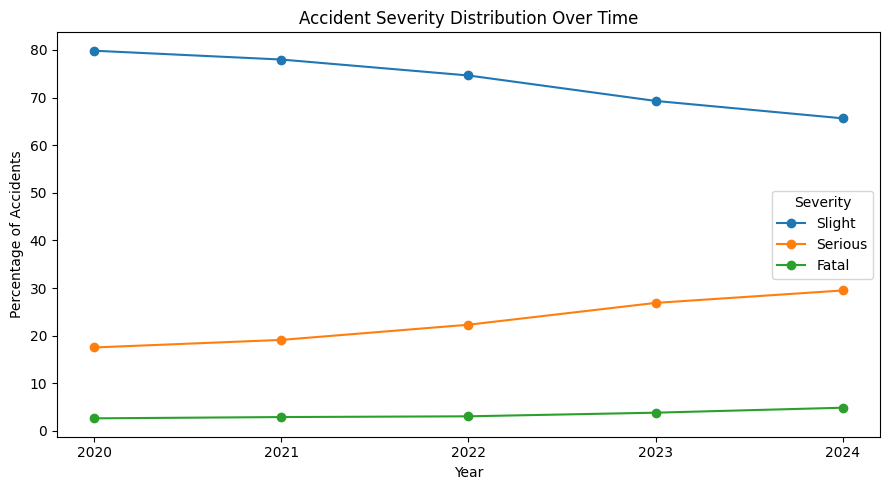

In [ ]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution[
    ["Slight", "Serious", "Fatal"]
].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Accident Severity Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage of Accidents")
plt.xticks(yearly_target_distribution.index)
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

In [61]:
missing_comparison = pd.DataFrame({
    "development_missing_%": dev_df.isna().mean() * 100,
    "test_missing_%": test_df.isna().mean() * 100
})

missing_comparison["difference"] = (
    missing_comparison["test_missing_%"]
    - missing_comparison["development_missing_%"]
)

missing_comparison[missing_comparison["difference"] != 0].sort_values(
    "difference",
    key=abs,
    ascending=False
).round(2)

,development_missing_%,test_missing_%,difference
ZOMET_LO_IRONI,87.31,85.10,-2.21
KVISH1,67.45,65.76,-1.69
KVISH2,67.93,66.29,-1.64
KM,67.50,66.01,-1.49
ZOMET_IRONI,68.58,69.80,1.22
REHOV2,68.58,69.80,1.22
REHOV1,37.39,37.81,0.42
Y,0.22,0.26,0.04
X,0.22,0.26,0.04
BAYIT,65.06,65.10,0.04


In [60]:
def find_unseen_categories(train_data, test_data):
    results = []

    for col in train_data.columns:
        if train_data[col].nunique() < 100:
            train_values = set(train_data[col].dropna().unique())
            test_values = set(test_data[col].dropna().unique())

            unseen = test_values - train_values

            if unseen:
                results.append({
                    "column": col,
                    "unseen_values": unseen
                })

    return pd.DataFrame(results)
find_unseen_categories(dev_df, test_df)

,column,unseen_values
0,SHNAT_TEUNA,{2024}
1,MAAMAD_MINIZIPALI,{78.0}
2,ZURAT_ISHUV,{51.0}
3,file,{h20241331}


### Split Observations

#### Target Distribution

The target distribution changes over time.

The proportion of serious and fatal accidents increases between 2020 and 2024, while the proportion of slight accidents decreases.

This temporal distribution shift makes the 2024 test set more challenging, but also provides a more realistic evaluation of the model's ability to generalize to future data.

#### Null Values

There is no significant difference in the percentage of null values between the train and test sets.

Most fields show almost no difference, and the largest differences are approximately 2%.

This suggests that there is no substantial missing-data drift between the train data and the 2024 test set.

#### Unseen Values

I checked for values that appear in the 2024 test set but do not appear in the 2020–2023 train data.

Four unseen values were found:

- `SHNAT_TEUNA = 2024` is expected because 2024 is reserved exclusively for the test set.
- `file = h20241331` is also expected because it identifies the 2024 source file.
- `MAAMAD_MINIZIPALI = 78.0` appears only in the test set.
- `ZURAT_ISHUV = 51.0` appears only in the test set.

The last two unseen categorical values will need to be handled during preprocessing.

## Data Overview

In [68]:
rows = []
for col in train_df.columns:
    non_null = train_df[col].dropna()

    sample_values = (
        non_null.astype(str)
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    rows.append({
        "column": col,
        "dtype": str(train_df[col].dtype),
        "unique": train_df[col].nunique(dropna=True),
        "missing_count": train_df[col].isna().sum(),
        "missing_%": round(train_df[col].isna().mean() * 100, 2),
        "sample_values": sample_values,
    })

statistics = pd.DataFrame(rows)
statistics


,column,dtype,unique,missing_count,missing_%,sample_values
0,pk_teuna_fikt,int64,41626,0,0.00,"[2020000003, 2020000009, 2020000014, 202000003..."
1,sug_tik,int64,1,0,0.00,[1]
2,THUM_GEOGRAFI,int64,2,0,0.00,"[1, 2]"
3,SUG_DEREH,int64,4,0,0.00,"[3, 1, 2, 4]"
4,SEMEL_YISHUV,int64,555,0,0.00,"[0, 6500, 8300, 7900, 8400]"
5,REHOV1,float64,2052,15566,37.39,"[602.0, 970.0, 424.0, 363.0, 1135.0]"
6,REHOV2,float64,1749,28546,68.58,"[609.0, 304.0, 905.0, 426.0, 2465.0]"
7,BAYIT,float64,266,27082,65.06,"[80.0, 140.0, 9999.0, 2.0, 90.0]"
8,ZOMET_IRONI,float64,5177,28546,68.58,"[210007.0, 9850054.0, 30051.0, 80230093.0, 149..."
9,KVISH1,float64,524,28075,67.45,"[461.0, 444.0, 85.0, 5803.0, 3875.0]"


## Data Dictionary
Based on [Codebook](https://www.cbs.gov.il/he/publications/DocLib1/2015/PUF/%D7%AA%D7%97%D7%91%D7%95%D7%A8%D7%94/H20131162AccCodebook.pdf)

| Field | Meaning |
|---|---|
| `PK_TEUNA_FIKT` | Synthetic accident identifier |
| `SUG_TIK` | File type |
| `THUM_GEOGRAFI` | Geographic area |
| `SUG_DEREH` | Road type |
| `SEMEL_YISHUV` | Locality code |
| `REHOV1` | Primary street code |
| `REHOV2` | Secondary street code |
| `MISPAR_BAIT` | House number |
| `ZOMET_IRONI` | Urban intersection code |
| `KVISH1` | Primary non-urban road number |
| `KVISH2` | Secondary non-urban road number |
| `KM` | Kilometer marker |
| `ZOMET_LO_IRONI` | Non-urban intersection code |
| `YEHIDA` | Police unit |
| `SHNAT_TEUNA` | Accident year |
| `HODESH_TEUNA` | Accident month |
| `YOM_BE_HODES` | Day of month |
| `SHAA` | Accident hour |
| `SUG_YOM` | Day type |
| `YOM_LAYLA` | Day / night |
| `YOM_BASHAVUA` | Day of week |
| `RAMZOR` | Traffic-light controlled intersection |
| `HUMRAT_TEUNA` | Accident severity |
| `SUG_TEUNA` | Accident type |
| `ZURAT_DEREH` | Road configuration |
| `HAD_MASLUL` | Single-carriageway configuration |
| `RAV_MASLUL` | Divided-road median type |
| `MEHIRUT_MUTERET` | Permitted speed |
| `TKINUT` | Road condition |
| `ROHAV` | Road width |
| `SIMUN_TIMRUR` | Road markings / traffic signs condition |
| `TEURA` | Lighting conditions |
| `BAKARA` | Intersection control type |
| `MEZEG_AVIR` | Weather conditions |
| `PNE_KVISH` | Road surface condition |
| `SUG_EZEM` | Type of stationary object struck |
| `MERHAK_EZEM` | Distance of stationary object from road |
| `LO_HAZA` | Pedestrian activity when not crossing |
| `OFEN_HAZIYA` | Pedestrian crossing behavior |
| `MEKOM_HAZIYA` | Pedestrian crossing location |
| `KIVUN_HAZIYA` | Pedestrian crossing direction |
| `MAHOZ` | District |
| `NAFA` | Subdistrict |
| `EZOR_TIVI` | Natural region |
| `MAAMAD_MINIZIPALI` | Municipal status |
| `ZURAT_ISHUV` | Locality type |
| `IGUN_MEKUBAZ` | Geocoding quality |
| `X_KORDINAT` | X coordinate |
| `Y_KORDINAT` | Y coordinate |

### Values Mapping

In [24]:
VALUE_LABELS = {
    "SUG_TIK": {
        3: "General, casualties, light",
    },

    "THUM_GEOGRAFI": {
        1: "Israel, excluding Judea and Samaria",
        2: "Judea and Samaria",
    },

    "SUG_DEREH": {
        1: "Urban, at intersection",
        2: "Non-urban, at intersection",
        3: "Urban, not at intersection",
        4: "Non-urban, not at intersection",
    },

    "YEHIDA": {
        11: "Hof Area (Haifa)",
        12: "Galilee Area",
        14: "Valleys Area",
        20: "Tel Aviv Area",
        33: "Eilat Area",
        34: "Negev Area",
        36: "Shimshon Area (until 1999)",
        37: "Shimshon Area (from 2004)",
        38: "Lachish Area",
        41: "Samaria Area",
        43: "Judea Area",
        51: "Sharon Area",
        52: "Shfela Area",
        61: "Jerusalem District",
    },

    "SUG_YOM": {
        1: "Holiday",
        2: "Holiday eve",
        3: "Intermediate festival day",
        4: "Other day",
    },

    "YOM_LAYLA": {
        1: "Day",
        5: "Night",
    },

    "YOM_BASHAVUA": {
        1: "Sunday",
        2: "Monday",
        3: "Tuesday",
        4: "Wednesday",
        5: "Thursday",
        6: "Friday",
        7: "Saturday",
    },

    "RAMZOR": {
        0: "No",
        1: "Yes",
        9: "Unknown",
    },

    "HUMRAT_TEUNA": {
        1: "Fatal",
        2: "Serious",
        3: "Slight",
    },

    "SUG_TEUNA": {
        1: "Collision with pedestrian",
        2: "Front-to-side collision",
        3: "Front-to-rear collision",
        4: "Side-to-side collision",
        5: "Head-on collision",
        6: "Collision with stopped vehicle, not parked",
        7: "Collision with parked vehicle",
        8: "Collision with stationary object",
        9: "Leaving roadway or mounting sidewalk",
        10: "Rollover",
        11: "Skidding",
        12: "Injury to passenger inside vehicle",
        13: "Fall from moving vehicle",
        14: "Fire",
        15: "Other",
        17: "Rear-to-front collision",
        18: "Rear-to-side collision",
        19: "Collision with animal",
        20: "Struck by vehicle cargo",
    },

    "ZURAT_DEREH": {
        1: "Entrance to interchange",
        2: "Exit from interchange",
        3: "Parking lot / gas station",
        4: "Steep grade",
        5: "Sharp curve",
        6: "Bridge / tunnel",
        7: "Railway crossing",
        8: "Straight road / intersection",
        9: "Other",
        10: "Bus stop / public transport lane",
    },

    "HAD_MASLUL": {
        1: "One-way",
        2: "Two-way with continuous dividing line",
        3: "Two-way without continuous dividing line",
        4: "Other",
        9: "Number of lanes unknown",
    },

    "RAV_MASLUL": {
        1: "Median marked with paint",
        2: "Median with safety barrier",
        3: "Built median without safety barrier",
        4: "Unbuilt median",
        5: "Other",
    },

    "MEHIRUT_MUTERET": {
        0: "Unknown",
        1: "Up to 50 km/h",
        2: "60 km/h",
        3: "70 km/h",
        4: "80 km/h",
        5: "90 km/h",
        6: "100 km/h",
        7: "110 km/h",
    },

    "TKINUT": {
        0: "Unknown",
        1: "No defect",
        2: "Poor shoulders",
        3: "Damaged road surface",
        4: "Poor shoulders and damaged road surface",
    },

    "ROHAV": {
        0: "Unknown",
        1: "Up to 5 m",
        2: "5 to 7 m",
        3: "7 to 10.5 m",
        4: "10.5 to 14 m",
        5: "Over 14 m",
    },

    "SIMUN_TIMRUR": {
        1: "Road markings defective or missing",
        2: "Traffic signs defective or missing",
        3: "No defect",
        4: "Traffic sign not required",
        5: "Unknown",
    },

    "TEURA": {
        1: "Normal daylight",
        2: "Limited visibility due to weather",
        3: "Night, lighting operational",
        4: "Lighting exists but defective or not operating",
        5: "Night, no lighting",
        6: "Night, unknown",
        7: "Night, proper lighting with limited visibility",
        8: "Night, defective lighting with limited visibility",
        9: "Night, no lighting with limited visibility",
        10: "Twilight",
        11: "Day, unknown",
    },

    "BAKARA": {
        1: "No control",
        2: "Traffic light functioning",
        3: "Flashing yellow traffic light",
        4: "Traffic light not functioning",
        5: "Stop sign",
        6: "Yield sign",
        7: "Other",
    },

    "MEZEG_AVIR": {
        1: "Clear",
        2: "Rainy",
        3: "Hot and dry",
        4: "Foggy",
        5: "Other",
        9: "Unknown",
    },

    "PNE_KVISH": {
        1: "Dry",
        2: "Wet",
        3: "Covered with fuel",
        4: "Covered with mud",
        5: "Sand or gravel on road",
        6: "Other",
        9: "Unknown",
    },

    "SUG_EZEM": {
        1: "Tree",
        2: "Utility pole",
        3: "Traffic sign / signboard",
        4: "Bridge and protective structures",
        5: "Structure",
        6: "Vehicle safety barrier",
        7: "Barrel",
        8: "Other",
        9: "Unknown",
    },

    "MERHAK_EZEM": {
        1: "Up to 1 m",
        2: "1 to 3 m",
        3: "On the road",
        4: "On the median",
        9: "Unknown",
    },

    "LO_HAZA": {
        1: "Walking in direction of traffic",
        2: "Walking against traffic",
        3: "Playing on the road",
        4: "Standing on the road",
        5: "On a traffic island / median",
        6: "On the shoulder / sidewalk",
        7: "Other",
        9: "Unknown",
    },

    "OFEN_HAZIYA": {
        1: "Darted into the road",
        2: "Crossed while obscured",
        3: "Crossed normally",
        4: "Other",
        8: "Did not cross",
        9: "Crossed, manner unknown",
    },

    "MEKOM_HAZIYA": {
        1: "Not at crosswalk, near intersection",
        2: "Not at crosswalk, not near intersection",
        3: "At crosswalk without traffic light",
        4: "At crosswalk with traffic light",
        9: "Crossing location unknown",
    },

    "KIVUN_HAZIYA": {
        1: "Right to left",
        2: "Left to right",
        9: "Unknown",
    },

    "IGUN_MEKUBAZ": {
        1: "Precise geocoding",
        2: "Settlement center",
        3: "Road center",
        4: "Kilometer marker center",
        9: "Not geocoded",
    },
}

## Fields Review

### HUMRAT_TEUNA (accident severity) - Target feature
Our target feature is HUMRAT_TEUNA, which mean the accident severity based on the other features

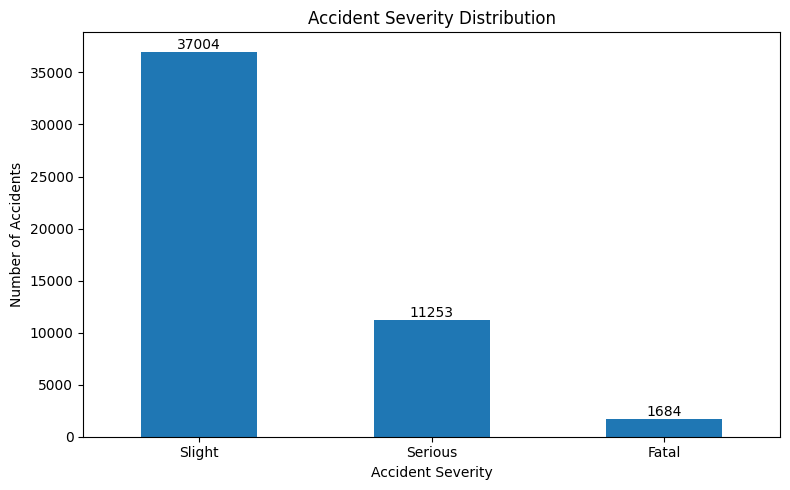

In [ ]:
severity_counts = (
    train_df["HUMRAT_TEUNA"]
    .map(VALUE_LABELS["HUMRAT_TEUNA"])
    .value_counts()
)

ax = severity_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Accident Severity Distribution")
ax.set_xlabel("Accident Severity")
ax.set_ylabel("Number of Accidents")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

In [29]:
severity_distribution = pd.DataFrame({
    "count": severity_counts,
    "percentage": severity_counts / severity_counts.sum() * 100
})

severity_distribution.round(2)

,count,percentage
HUMRAT_TEUNA,,
Fatal,1684,3.37
Serious,11253,22.53
Slight,37004,74.10


The target is imbalanced, with slight accidents representing the majority of cases.
Fatal accidents account for only 3.37% of the dataset, so accuracy alone will not be
a sufficient evaluation metric. Macro F1 and per-class precision/recall will be used.

### SUG_TEUNA (Accident Type)


First, I will review the accident types we have

In [69]:
accident_type_counts = (
    train_df["SUG_TEUNA"]
    .map(VALUE_LABELS["SUG_TEUNA"])
    .value_counts()
    .rename_axis("accident_type")
    .reset_index(name="count")
)

accident_type_counts["percentage"] = (
    accident_type_counts["count"] / len(train_df) * 100
).round(2)

accident_type_counts

,accident_type,count,percentage
0,Front-to-side collision,15772,37.89
1,Collision with pedestrian,9502,22.83
2,Side-to-side collision,3668,8.81
3,Front-to-rear collision,3568,8.57
4,Head-on collision,3142,7.55
5,Collision with stationary object,1795,4.31
6,Skidding,1073,2.58
7,Rollover,1053,2.53
8,Other,533,1.28
9,Collision with parked vehicle,475,1.14


Front-to-side collision and Collision with pedestrian are represent almost 61% of the accidents

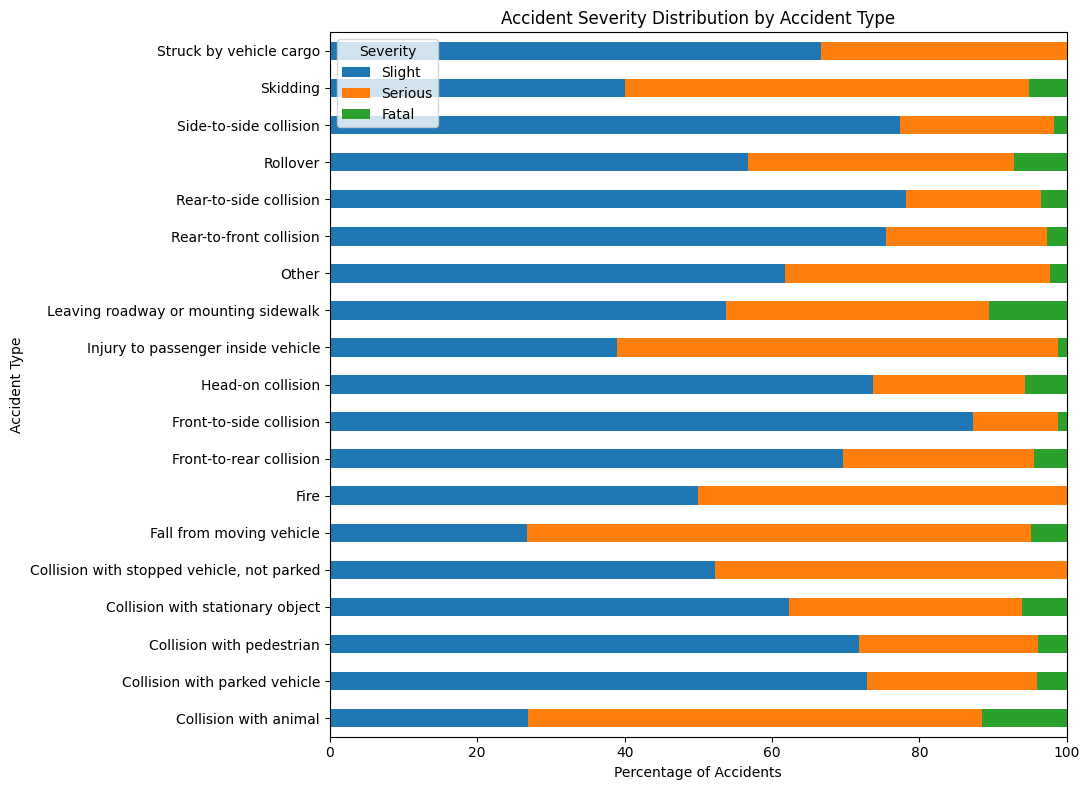

In [70]:
analysis_df = train_df.assign(
    accident_type=train_df["SUG_TEUNA"].map(VALUE_LABELS["SUG_TEUNA"]),
    severity=train_df["HUMRAT_TEUNA"].map(VALUE_LABELS["HUMRAT_TEUNA"])
)

severity_by_type = (
    pd.crosstab(
        analysis_df["accident_type"],
        analysis_df["severity"],
        normalize="index"
    ) * 100
)

severity_by_type = severity_by_type[
    ["Slight", "Serious", "Fatal"]
]

severity_by_type.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8)
)

plt.title("Accident Severity Distribution by Accident Type")
plt.xlabel("Percentage of Accidents")
plt.ylabel("Accident Type")
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

The following table show us the relation between the accident type to the accident severity.
Each row represent:
- accident_type
- count: how many accident of this type
- fatal_rate: how many of them classified as fatal
- serious_rate: how many of them classified as serious
- slight_rate: how many of them classified as serious
- severe_rate: accidents that wasn't classified as slight (fatal_rate + serious_rate)

In [ ]:
type_summary["severe_rate"] = (
    type_summary["fatal_rate"] +
    type_summary["serious_rate"]
)

type_summary.sort_values(
    "severe_rate",
    ascending=False
).round(2)

,count,fatal_rate,serious_rate,slight_rate,severe_rate
accident_type,,,,,
Collision with animal,30,10.00,66.67,23.33,76.67
Fall from moving vehicle,218,5.05,67.89,27.06,72.94
Injury to passenger inside vehicle,405,0.99,62.47,36.54,63.46
Skidding,1309,5.81,57.45,36.75,63.25
Fire,2,0.00,50.00,50.00,50.00
Leaving roadway or mounting sidewalk,251,11.16,38.25,50.60,49.40
Rollover,1274,7.77,37.28,54.95,45.05
"Collision with stopped vehicle, not parked",64,0.00,43.75,56.25,43.75
Collision with stationary object,2128,6.48,34.30,59.21,40.79


We can see high correlation between the accident type and the severity 
Some insights from this table:
- Collision with animal have the highest severe_rate, but they also have very low amount of accidents (0.06%)
- Other high severe rate are: Fall from moving vehicle (218)
- Front-to-side collision is usually cause to light accident severity

### SUG_TEUNA (Accident Type)


### SUG_TEUNA (Accident Type)
